In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
aapl = yf.download(
    "AAPL",
    period="5y",
    auto_adjust=True,
    progress=False
)

aapl.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-06-21,128.959686,129.066910,125.947706,127.010182,79663300
2021-06-22,130.597229,130.694710,128.296814,128.793947,74783600
2021-06-23,130.324326,130.928682,129.866191,130.392565,60214200
2021-06-24,130.041641,131.240582,129.573750,131.055377,68711000
2021-06-25,129.749252,130.509558,129.456824,130.090422,70783700


In [5]:
tickers = ["AAPL", "MSFT", "NVDA", "JPM"]

close_prices = pd.DataFrame()

for ticker in tickers:

    temp = yf.download(
        ticker,
        period="5y",
        auto_adjust=True,
        progress=False
    )

    close_prices[ticker] = temp["Close"]

close_prices.head()

,AAPL,MSFT,NVDA,JPM
Date,,,,
2021-06-21,128.959671,252.045151,18.363733,132.574417
2021-06-22,130.597260,254.809082,18.821648,132.380508
2021-06-23,130.324326,254.578735,18.991560,133.182495
2021-06-24,130.041687,255.941513,19.139301,134.407486
2021-06-25,129.749222,254.338791,18.965399,135.764725


In [6]:
daily_returns = close_prices.pct_change().dropna()

daily_returns.head()

,AAPL,MSFT,NVDA,JPM
Date,,,,
2021-06-22,0.012698,0.010966,0.024936,-0.001463
2021-06-23,-0.002090,-0.000904,0.009027,0.006058
2021-06-24,-0.002169,0.005353,0.007779,0.009198
2021-06-25,-0.002249,-0.006262,-0.009086,0.010098
2021-06-28,0.012546,0.013961,0.050129,0.001818


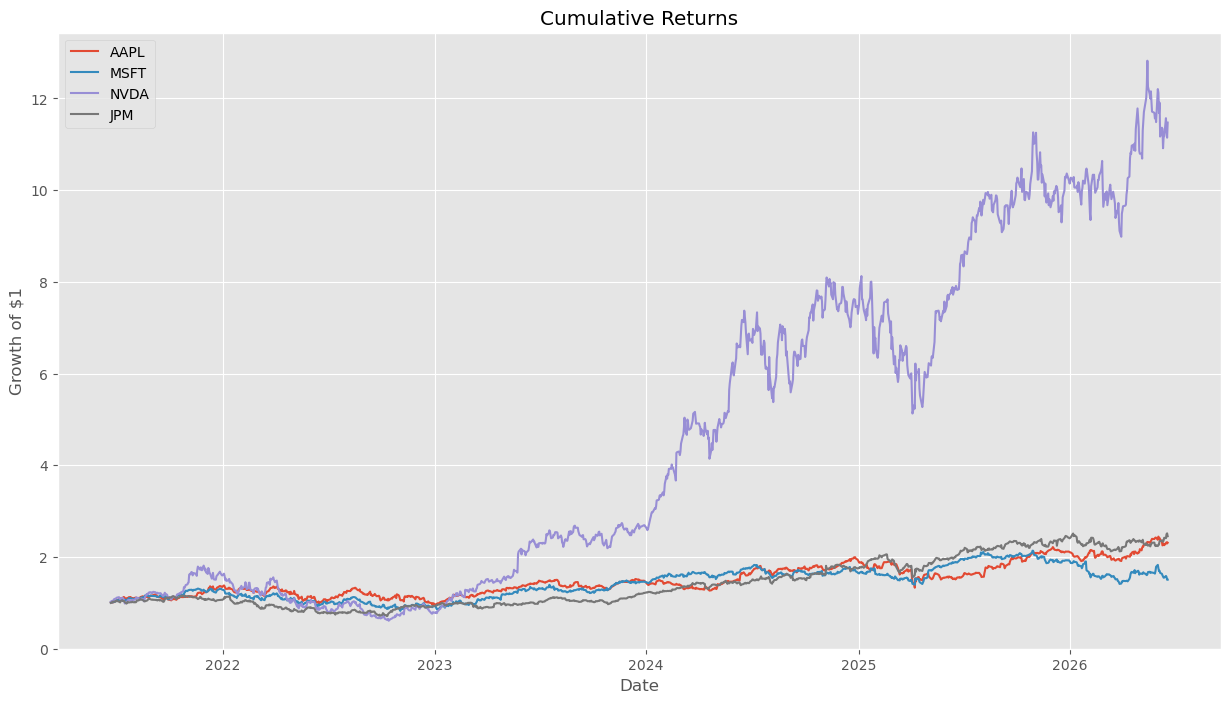

In [7]:
cumulative_returns = (1 + daily_returns).cumprod()

plt.figure(figsize=(15,8))

for stock in cumulative_returns.columns:
    plt.plot(cumulative_returns[stock], label=stock)

plt.title("Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()

plt.show()

In [8]:
stats = pd.DataFrame()

stats["Annual Return"] = daily_returns.mean() * 252
stats["Annual Volatility"] = daily_returns.std() * np.sqrt(252)

stats

,Annual Return,Annual Volatility
AAPL,0.206056,0.275252
MSFT,0.117935,0.267449
NVDA,0.623480,0.518073
JPM,0.210249,0.244588


In [9]:
risk_free_rate = 0.04

stats["Sharpe Ratio"] = (
    stats["Annual Return"] - risk_free_rate
) / stats["Annual Volatility"]

stats

,Annual Return,Annual Volatility,Sharpe Ratio
AAPL,0.206056,0.275252,0.603287
MSFT,0.117935,0.267449,0.291403
NVDA,0.623480,0.518073,1.126252
JPM,0.210249,0.244588,0.696066


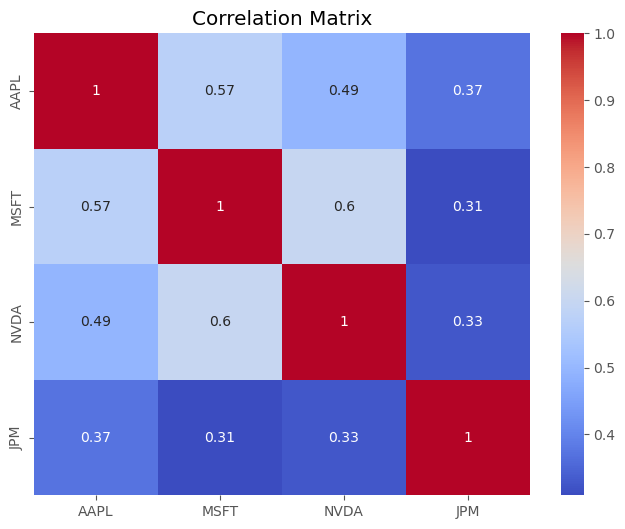

In [10]:
correlation_matrix = daily_returns.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

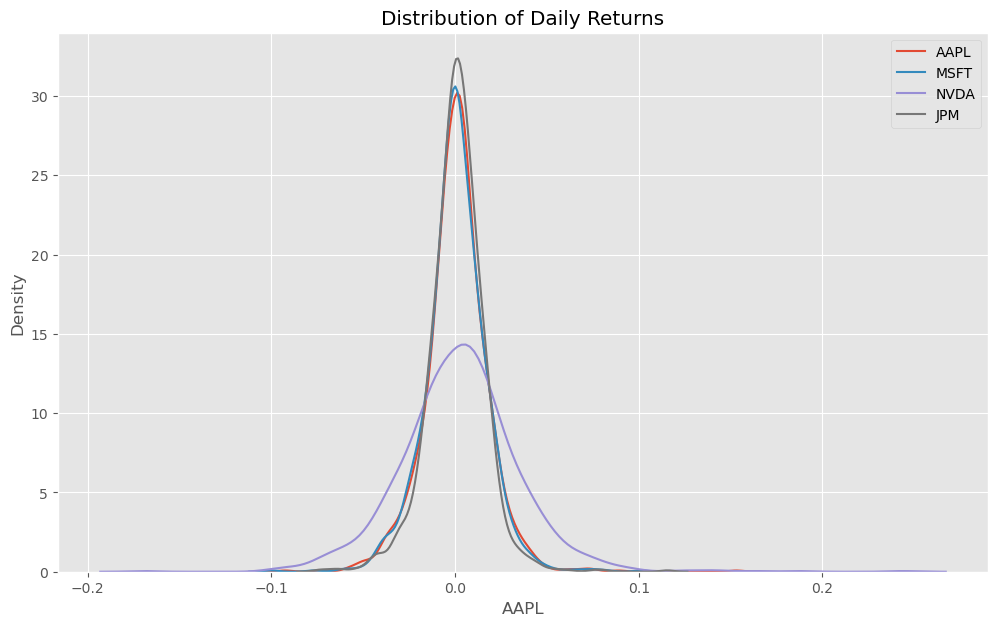

In [11]:
plt.figure(figsize=(12,7))

for stock in daily_returns.columns:
    sns.kdeplot(daily_returns[stock], label=stock)

plt.title("Distribution of Daily Returns")

plt.legend()

plt.show()

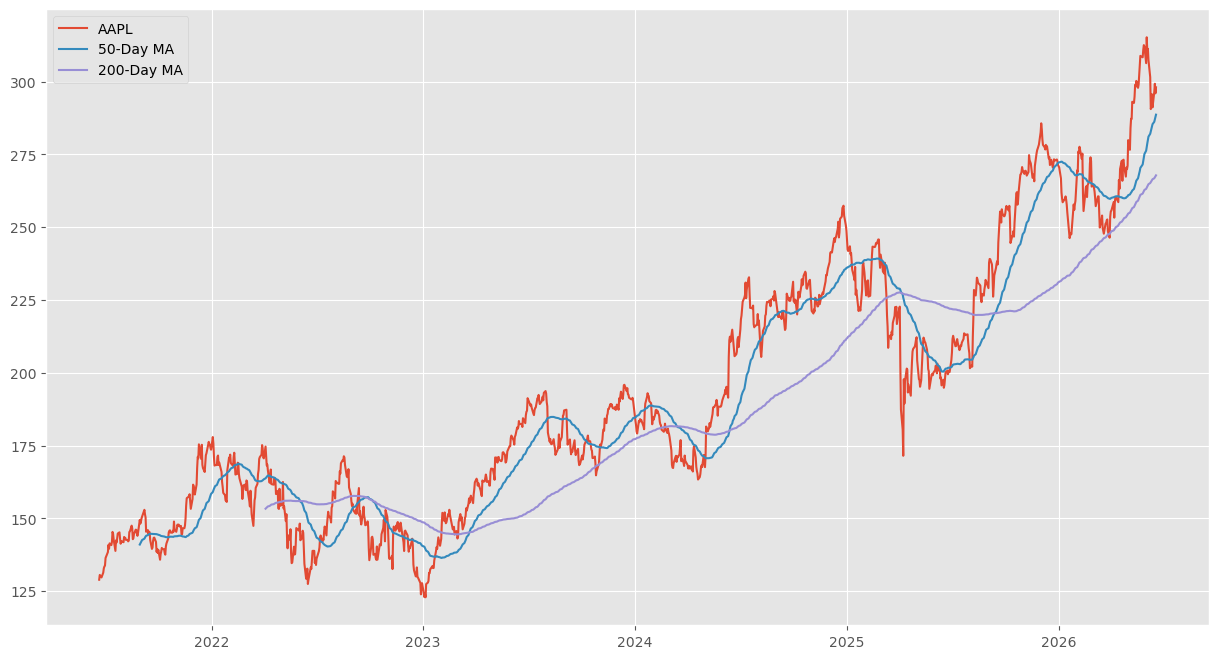

In [12]:
plt.figure(figsize=(15,8))

aapl = close_prices["AAPL"]

ma50 = aapl.rolling(50).mean()
ma200 = aapl.rolling(200).mean()

plt.plot(aapl, label="AAPL")
plt.plot(ma50, label="50-Day MA")
plt.plot(ma200, label="200-Day MA")

plt.legend()

plt.show()

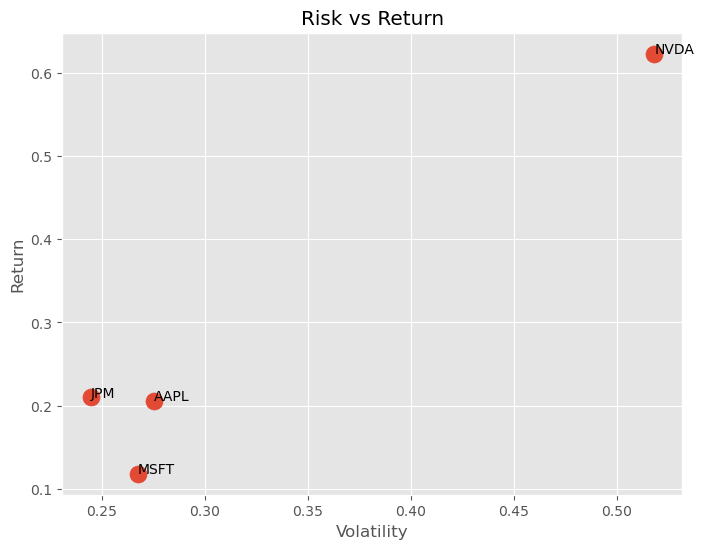

In [13]:
annual_returns = daily_returns.mean() * 252
annual_volatility = daily_returns.std() * np.sqrt(252)

plt.figure(figsize=(8,6))

plt.scatter(
    annual_volatility,
    annual_returns,
    s=150
)

for stock in annual_returns.index:
    plt.annotate(
        stock,
        (
            annual_volatility[stock],
            annual_returns[stock]
        )
    )

plt.xlabel("Volatility")
plt.ylabel("Return")

plt.title("Risk vs Return")

plt.show()

In [14]:
weights = np.array([0.25, 0.25, 0.25, 0.25])

weights

array([0.25, 0.25, 0.25, 0.25])

In [15]:
annual_returns = daily_returns.mean() * 252

portfolio_return = np.sum(weights * annual_returns)

print("Expected Annual Return:", round(portfolio_return*100,2), "%")

Expected Annual Return: 28.94 %


In [16]:
cov_matrix = daily_returns.cov() * 252

portfolio_volatility = np.sqrt(
    np.dot(
        weights.T,
        np.dot(cov_matrix, weights)
    )
)

print("Annual Volatility:", round(portfolio_volatility*100,2), "%")

Annual Volatility: 25.49 %


In [17]:
risk_free_rate = 0.04

sharpe_ratio = (
    portfolio_return - risk_free_rate
) / portfolio_volatility

print("Portfolio Sharpe Ratio:", round(sharpe_ratio,3))

Portfolio Sharpe Ratio: 0.979


In [19]:
initial_investment = 100000

num_simulations = 1000
trading_days = 252

simulation_results = np.zeros((trading_days, num_simulations))

for i in range(num_simulations):

    portfolio_value = initial_investment

    values = []

    for day in range(trading_days):

        daily_portfolio_return = np.random.normal(
            portfolio_return/252,
            portfolio_volatility/np.sqrt(252)
        )

        portfolio_value *= (1 + daily_portfolio_return)

        values.append(portfolio_value)

    simulation_results[:, i] = values

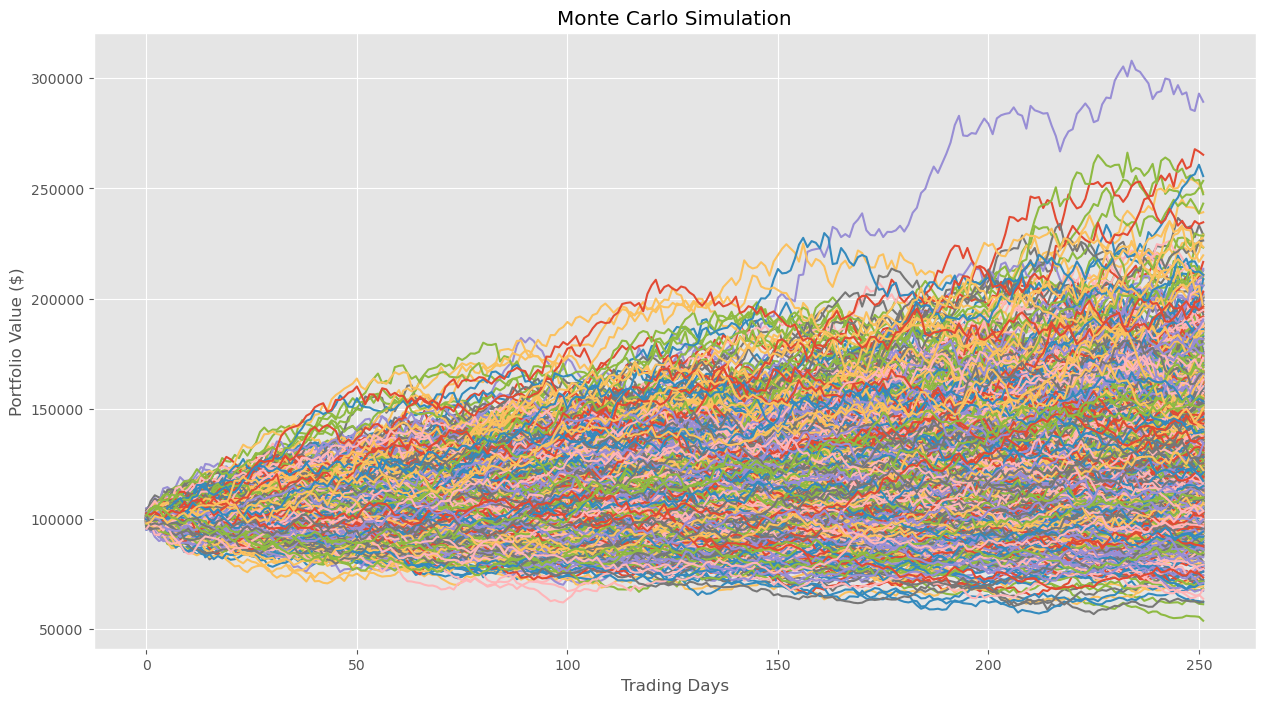

In [20]:
plt.figure(figsize=(15,8))

plt.plot(simulation_results)

plt.title("Monte Carlo Simulation")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value ($)")

plt.show()

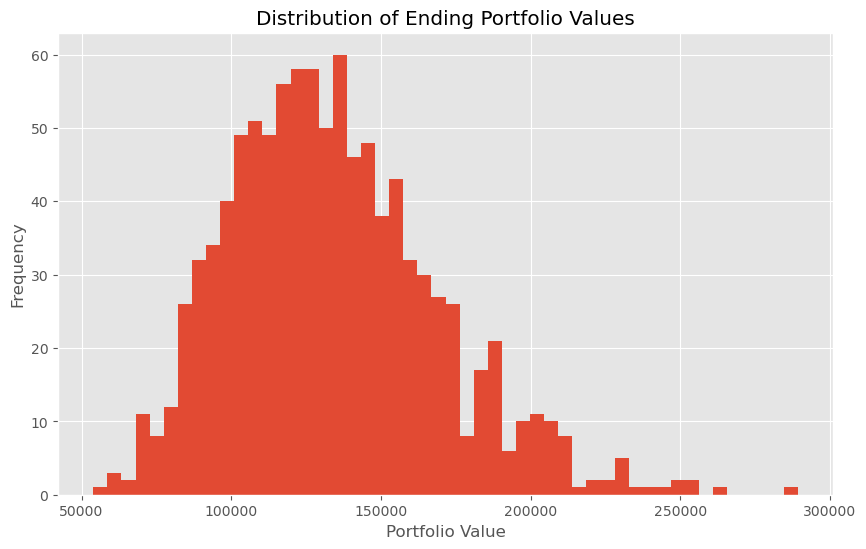

In [21]:
ending_values = simulation_results[-1]

plt.figure(figsize=(10,6))

plt.hist(
    ending_values,
    bins=50
)

plt.title("Distribution of Ending Portfolio Values")

plt.xlabel("Portfolio Value")
plt.ylabel("Frequency")

plt.show()

In [22]:
mean_value = np.mean(ending_values)

percentile_5 = np.percentile(
    ending_values,
    5
)

percentile_95 = np.percentile(
    ending_values,
    95
)

print("Mean Portfolio Value:", round(mean_value,2))

print("5th Percentile:", round(percentile_5,2))

print("95th Percentile:", round(percentile_95,2))

Mean Portfolio Value: 133907.01
5th Percentile: 85523.08
95th Percentile: 199014.19


In [23]:
VaR_95 = initial_investment - percentile_5

print("Value at Risk (95% confidence):")

print("$", round(VaR_95,2))

Value at Risk (95% confidence):
$ 14476.92


In [24]:
num_portfolios = 10000

portfolio_returns = []
portfolio_volatilities = []
portfolio_sharpe = []
portfolio_weights = []

for i in range(num_portfolios):

    weights = np.random.random(len(tickers))

    weights /= np.sum(weights)

    annual_return = np.sum(weights * annual_returns)

    annual_volatility = np.sqrt(
        np.dot(
            weights.T,
            np.dot(cov_matrix, weights)
        )
    )

    sharpe_ratio = (
        annual_return - risk_free_rate
    ) / annual_volatility

    portfolio_returns.append(annual_return)
    portfolio_volatilities.append(annual_volatility)
    portfolio_sharpe.append(sharpe_ratio)
    portfolio_weights.append(weights)

In [25]:
portfolio_df = pd.DataFrame()

portfolio_df["Return"] = portfolio_returns
portfolio_df["Volatility"] = portfolio_volatilities
portfolio_df["Sharpe Ratio"] = portfolio_sharpe

portfolio_df.head()

,Return,Volatility,Sharpe Ratio
0,0.292832,0.239261,1.056718
1,0.359707,0.313009,1.021397
2,0.507957,0.419801,1.114712
3,0.272097,0.234957,0.987828
4,0.342205,0.300282,1.006404


In [26]:
for i, ticker in enumerate(tickers):

    portfolio_df[ticker + " Weight"] = [
        weights[i]
        for weights in portfolio_weights
    ]

portfolio_df.head()

,Return,Volatility,Sharpe Ratio,AAPL Weight,MSFT Weight,NVDA Weight,JPM Weight
0,0.292832,0.239261,1.056718,0.305496,0.013098,0.205873,0.475533
1,0.359707,0.313009,1.021397,0.292278,0.219729,0.413733,0.074260
2,0.507957,0.419801,1.114712,0.046134,0.109177,0.745296,0.099393
3,0.272097,0.234957,0.987828,0.330878,0.129486,0.181952,0.357684
4,0.342205,0.300282,1.006404,0.271610,0.248397,0.377575,0.102419


In [27]:
max_sharpe_idx = portfolio_df["Sharpe Ratio"].idxmax()

best_portfolio = portfolio_df.loc[max_sharpe_idx]

best_portfolio

Return          0.457225
Volatility      0.355303
Sharpe Ratio    1.174279
AAPL Weight     0.012690
MSFT Weight     0.008988
NVDA Weight     0.599807
JPM Weight      0.378515
Name: 8394, dtype: float64

In [28]:
print("Optimal Portfolio")

for ticker in tickers:

    print(
        ticker,
        ":",
        round(
            best_portfolio[ticker + " Weight"]*100,
            2
        ),
        "%"
    )

print()

print(
    "Expected Return:",
    round(best_portfolio["Return"]*100,2),
    "%"
)

print(
    "Volatility:",
    round(best_portfolio["Volatility"]*100,2),
    "%"
)

print(
    "Sharpe Ratio:",
    round(best_portfolio["Sharpe Ratio"],3)
)

Optimal Portfolio
AAPL : 1.27 %
MSFT : 0.9 %
NVDA : 59.98 %
JPM : 37.85 %

Expected Return: 45.72 %
Volatility: 35.53 %
Sharpe Ratio: 1.174


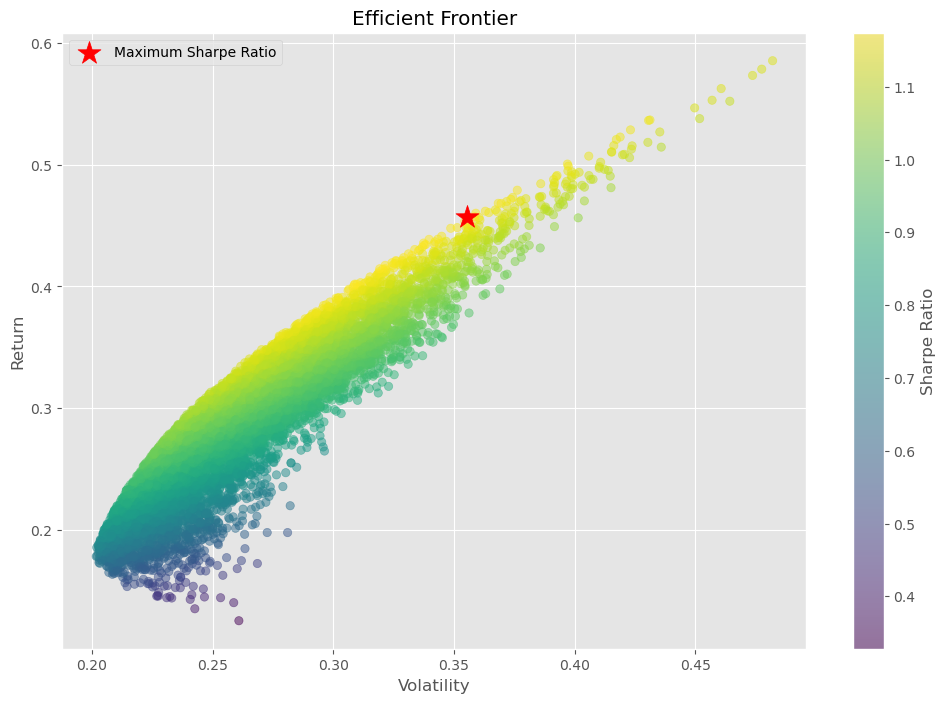

In [29]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    portfolio_volatilities,
    portfolio_returns,
    c=portfolio_sharpe,
    cmap="viridis",
    alpha=0.5
)

plt.colorbar(label="Sharpe Ratio")

plt.scatter(
    best_portfolio["Volatility"],
    best_portfolio["Return"],
    color="red",
    s=300,
    marker="*",
    label="Maximum Sharpe Ratio"
)

plt.xlabel("Volatility")
plt.ylabel("Return")

plt.title("Efficient Frontier")

plt.legend()

plt.show()

In [30]:
portfolio_df.to_excel(
    "portfolio_analysis.xlsx",
    index=False
)

print("Excel file saved successfully")

Excel file saved successfully


In [31]:
stats.sort_values(
    "Sharpe Ratio",
    ascending=False
)

,Annual Return,Annual Volatility,Sharpe Ratio
NVDA,0.623480,0.518073,1.126252
JPM,0.210249,0.244588,0.696066
AAPL,0.206056,0.275252,0.603287
MSFT,0.117935,0.267449,0.291403


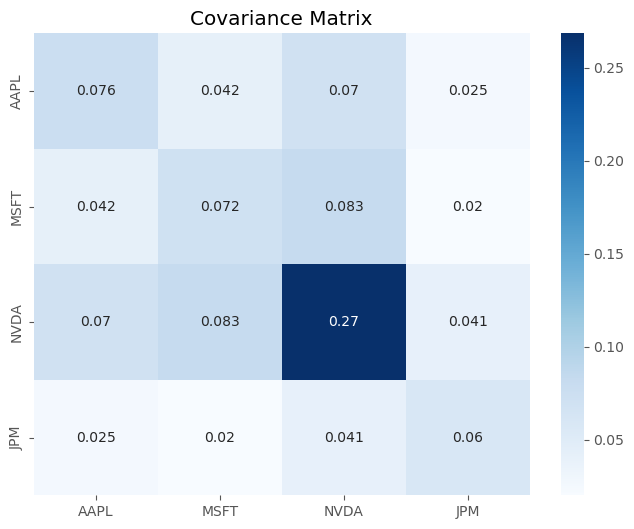

In [32]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cov_matrix,
    annot=True,
    cmap="Blues"
)

plt.title("Covariance Matrix")

plt.show()

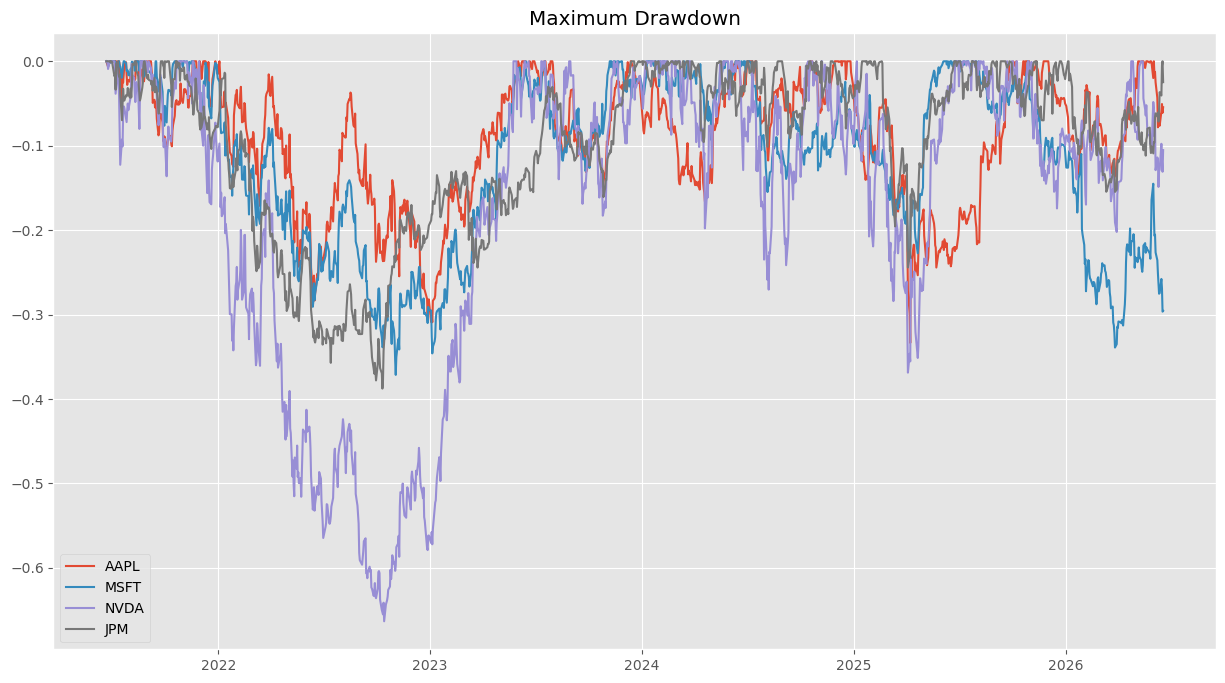

In [33]:
running_max = cumulative_returns.cummax()

drawdown = (
    cumulative_returns -
    running_max
) / running_max

plt.figure(figsize=(15,8))

for stock in drawdown.columns:
    plt.plot(
        drawdown[stock],
        label=stock
    )

plt.title("Maximum Drawdown")

plt.legend()

plt.show()

In [35]:
spy = yf.download(
    "SPY",
    period="5y",
    auto_adjust=True,
    progress=False
)

spy_returns = spy["Close"].pct_change().dropna()

betas = {}

for stock in tickers:

    # Combinar ambas series y eliminar fechas faltantes
    df = pd.concat(
        [daily_returns[stock], spy_returns],
        axis=1
    ).dropna()

    df.columns = ["Stock", "SPY"]

    covariance = df["Stock"].cov(df["SPY"])

    variance = df["SPY"].var()

    beta = covariance / variance

    betas[stock] = beta

beta_df = pd.DataFrame(
    betas.items(),
    columns=["Stock", "Beta"]
)

beta_df

,Stock,Beta
0,AAPL,1.201029
1,MSFT,1.124113
2,NVDA,2.129484
3,JPM,0.887538


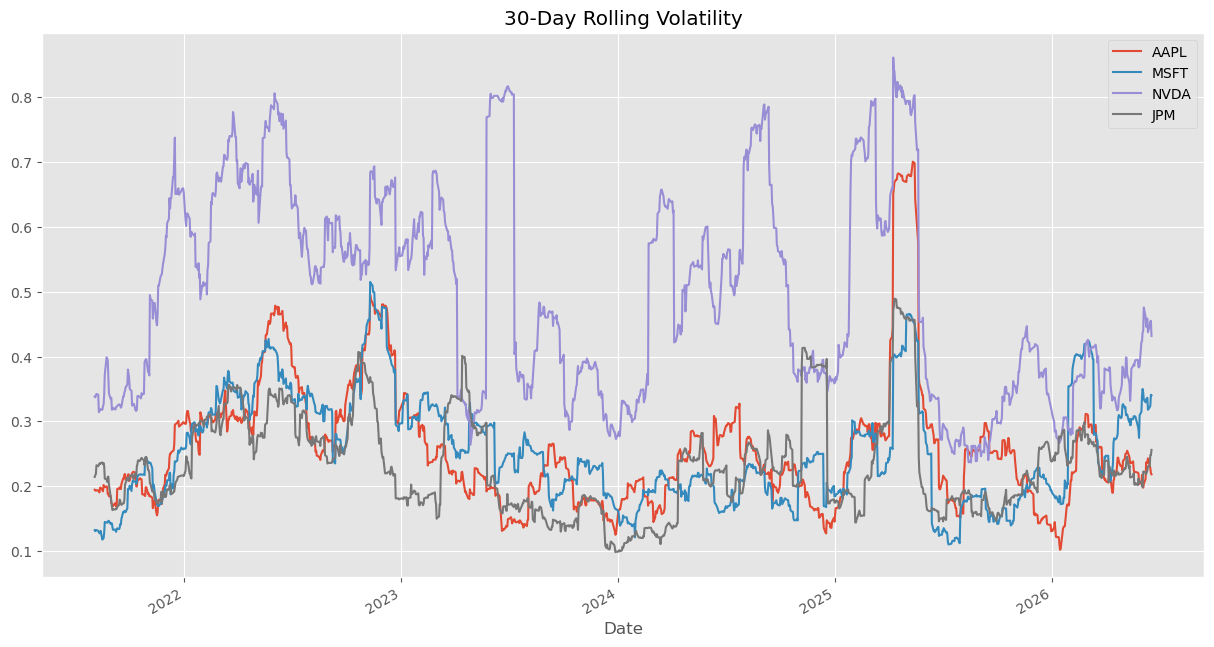

In [36]:
rolling_volatility = (
    daily_returns
    .rolling(30)
    .std()
    * np.sqrt(252)
)

rolling_volatility.plot(
    figsize=(15,8)
)

plt.title(
    "30-Day Rolling Volatility"
)

plt.show()

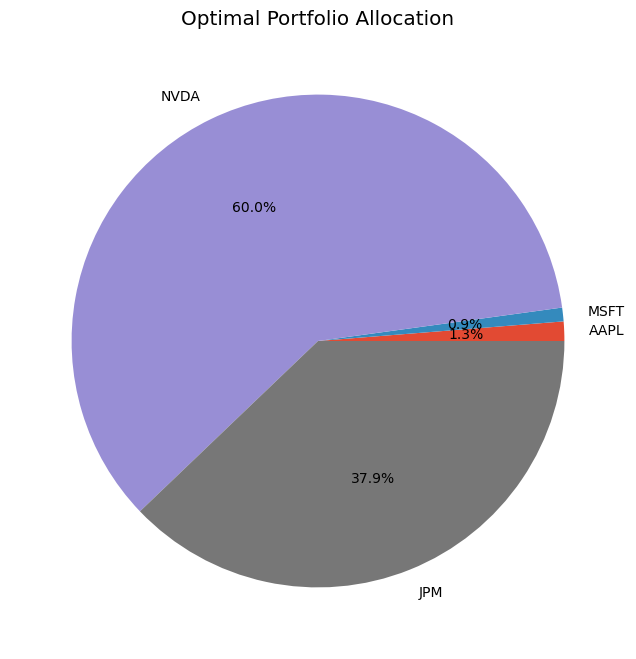

In [37]:
plt.figure(figsize=(8,8))

plt.pie(
    best_portfolio[
        [
            "AAPL Weight",
            "MSFT Weight",
            "NVDA Weight",
            "JPM Weight"
        ]
    ],

    labels=tickers,

    autopct="%1.1f%%"
)

plt.title(
    "Optimal Portfolio Allocation"
)

plt.show()

In [38]:
market_return = spy_returns.mean() * 252

risk_free_rate = 0.04

capm_returns = {}

for stock in tickers:

    beta = betas[stock]

    expected_return = (
        risk_free_rate +
        beta * (market_return - risk_free_rate)
    )

    capm_returns[stock] = expected_return

capm_df = pd.DataFrame(
    capm_returns.items(),
    columns=["Stock", "CAPM Expected Return"]
)

capm_df

,Stock,CAPM Expected Return
0,AAPL,Ticker SPY 0.164304 dtype: float64
1,MSFT,Ticker SPY 0.156343 dtype: float64
2,NVDA,Ticker SPY 0.260397 dtype: float64
3,JPM,Ticker SPY 0.131858 dtype: float64


In [39]:
comparison = pd.DataFrame()

comparison["Actual Return"] = annual_returns
comparison["CAPM Return"] = pd.Series(capm_returns)

comparison

,Actual Return,CAPM Return
AAPL,0.206056,Ticker SPY 0.164304 dtype: float64
MSFT,0.117935,Ticker SPY 0.156343 dtype: float64
NVDA,0.623480,Ticker SPY 0.260397 dtype: float64
JPM,0.210249,Ticker SPY 0.131858 dtype: float64


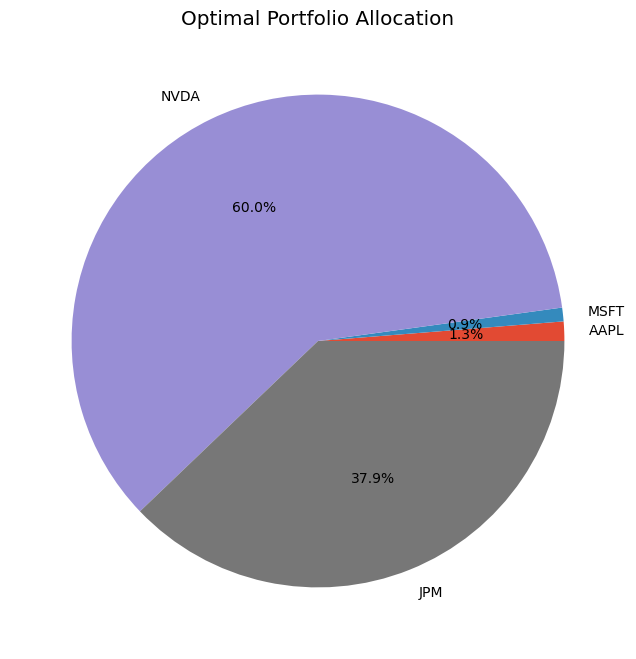

In [40]:
weights = []

for ticker in tickers:

    weights.append(
        best_portfolio[
            ticker + " Weight"
        ]
    )

plt.figure(figsize=(8,8))

plt.pie(
    weights,
    labels=tickers,
    autopct="%1.1f%%"
)

plt.title(
    "Optimal Portfolio Allocation"
)

plt.show()

In [43]:
summary = pd.DataFrame({

    "Metric": [
        "Expected Return",
        "Volatility",
        "Sharpe Ratio",
        "Value at Risk"
    ],

    "Value": [
        portfolio_return,
        portfolio_volatility,
        sharpe_ratio,
        VaR_95
    ]

})

summary

,Metric,Value
0,Expected Return,0.289430
1,Volatility,0.254879
2,Sharpe Ratio,1.037015
3,Value at Risk,14476.915607


In [44]:
with pd.ExcelWriter(
    "Financial_Portfolio_Report.xlsx",
    engine="openpyxl"
) as writer:

    stats.to_excel(
        writer,
        sheet_name="Stock Statistics"
    )

    portfolio_df.to_excel(
        writer,
        sheet_name="Efficient Frontier"
    )

    beta_df.to_excel(
        writer,
        sheet_name="Betas"
    )

    summary.to_excel(
        writer,
        sheet_name="Portfolio Summary"
    )

print("Excel report created successfully")

Excel report created successfully


In [45]:
!pip install scipy

In [46]:
from scipy.optimize import minimize

num_assets = len(tickers)

def portfolio_performance(weights):
    ret = np.sum(weights * annual_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return ret, vol

def negative_sharpe(weights):
    ret, vol = portfolio_performance(weights)
    return -(ret - risk_free_rate)/vol

constraints = ({
    'type': 'eq',
    'fun': lambda x: np.sum(x) - 1
})

bounds = tuple((0,1) for _ in range(num_assets))

initial_weights = np.ones(num_assets)/num_assets

optimal = minimize(
    negative_sharpe,
    initial_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

optimal_weights = optimal.x

optimal_weights

array([3.69886605e-17, 6.53529499e-17, 5.63074150e-01, 4.36925850e-01])

In [47]:
optimal_df = pd.DataFrame({
    "Stock": tickers,
    "Weight": optimal_weights
})

optimal_df["Weight"] = optimal_df["Weight"]*100

optimal_df

,Stock,Weight
0,AAPL,3.698866e-15
1,MSFT,6.535295e-15
2,NVDA,5.630742e+01
3,JPM,4.369258e+01


In [48]:
plt.savefig(
    "efficient_frontier.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [49]:
plt.savefig(
    "monte_carlo.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [50]:
plt.savefig(
    "correlation_matrix.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [52]:
summary.to_csv(
    "portfolio_summary.csv",
    index=False
)

optimal_df.to_csv(
    "optimal_weights.csv",
    index=False
)

In [53]:
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer
)

from reportlab.lib.styles import getSampleStyleSheet

doc = SimpleDocTemplate(
    "Portfolio_Report.pdf"
)

styles = getSampleStyleSheet()

story = []

story.append(
    Paragraph(
        "Financial Portfolio Analyzer Report",
        styles['Title']
    )
)

story.append(Spacer(1,20))

story.append(
    Paragraph(
        f"Expected Return: {round(portfolio_return*100,2)}%",
        styles['Normal']
    )
)

story.append(
    Paragraph(
        f"Volatility: {round(portfolio_volatility*100,2)}%",
        styles['Normal']
    )
)

story.append(
    Paragraph(
        f"Sharpe Ratio: {round(sharpe_ratio,2)}",
        styles['Normal']
    )
)

story.append(
    Paragraph(
        f"Value at Risk: ${round(VaR_95,2)}",
        styles['Normal']
    )
)

doc.build(story)

print("PDF created successfully")

PDF created successfully


In [54]:
!pip freeze > requirements.txt